# poropack: 3D Porous Media & Digital Rock Physics Generator
### Modernized and Extended Suite for Digital Rock Physics (DRP)

`poropack` is a comprehensive Python library for generating, diagenetically transforming, and petrophysically characterizing 3D multi-purpose porous media (granular assemblies, continuum random fields, and synthetic digital rocks).

#### Key Capabilities:
1. **Decoupled Architecture**: High-precision Lagrangian particle assemblies (`GrainPack`) and Eulerian voxel grids (`VoxelGrid`).
2. **Accelerated Spatial Indexing**: $O(1)$ spatial hash grid collision detection (`PeriodicSpatialGrid`) replacing $O(N^2)$ brute-force.
3. **Continuous PSD**: Geological grain size distributions (Log-Normal, Weibull, Truncated Gaussian, Sieve curves) with analytical Hatch-Choate volume-to-number conversion.
4. **Physically-Grounded Generation**:
   - Accelerated **RSA** (Random Sequential Adsorption) with periodic boundary conditions.
   - 3D **Ballistic Sedimentation** ("Drop-and-Roll") under gravity with 4-stage analytical kinematics and contact tracking.
   - **Dense Random Packing** via Force-Biased Algorithm (FBA) + FIRE optimization breaking the RSA jamming limit.
   - **Continuum Bicontinuous Media** via 3D Spectral Gaussian Random Fields (GRF) and Quartet Structure Generation Set (QSGS).
5. **Diagenetic Transformations**: Mechanical vertical compaction (uniaxial strain tensor) and morphological cementation/dissolution (Euclidean distance transform dilation).
6. **Digital Rock Petrophysics**: Total/effective/isolated porosity partitioning, specific surface area $S_v$, two-point autocorrelation $S_2(r)$, chord length distribution, Kozeny-Carman permeability, and PoreSpy SNOW2 pore network extraction.
7. **Simulation & Visualization I/O**: Direct export to 3D TIFF stacks, VTK (`.vti`/`.vtp`), raw binary, CSV, and MRST-ready MATLAB `.mat` structs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import poropack as pp

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f'poropack version: {pp.__version__}')


poropack version: 2.0.0


---
## 1. Continuous Geological Particle Size Distributions (PSD)

In reservoir geology and Digital Rock Physics, grain sizes follow continuous statistical distributions defined by sedimentological parameters (e.g. median diameter $d_{50}$ and Folk-Ward sorting coefficient $\sigma_\phi$).

When sieve analysis measures volume/mass-weighted diameters, `poropack` automatically converts to a number-weighted sampling density using the analytical **Hatch-Choate equation**:
$$\ln(d_{50,N}) = \ln(d_{50,V}) - 3 (\ln \sigma_g)^2$$


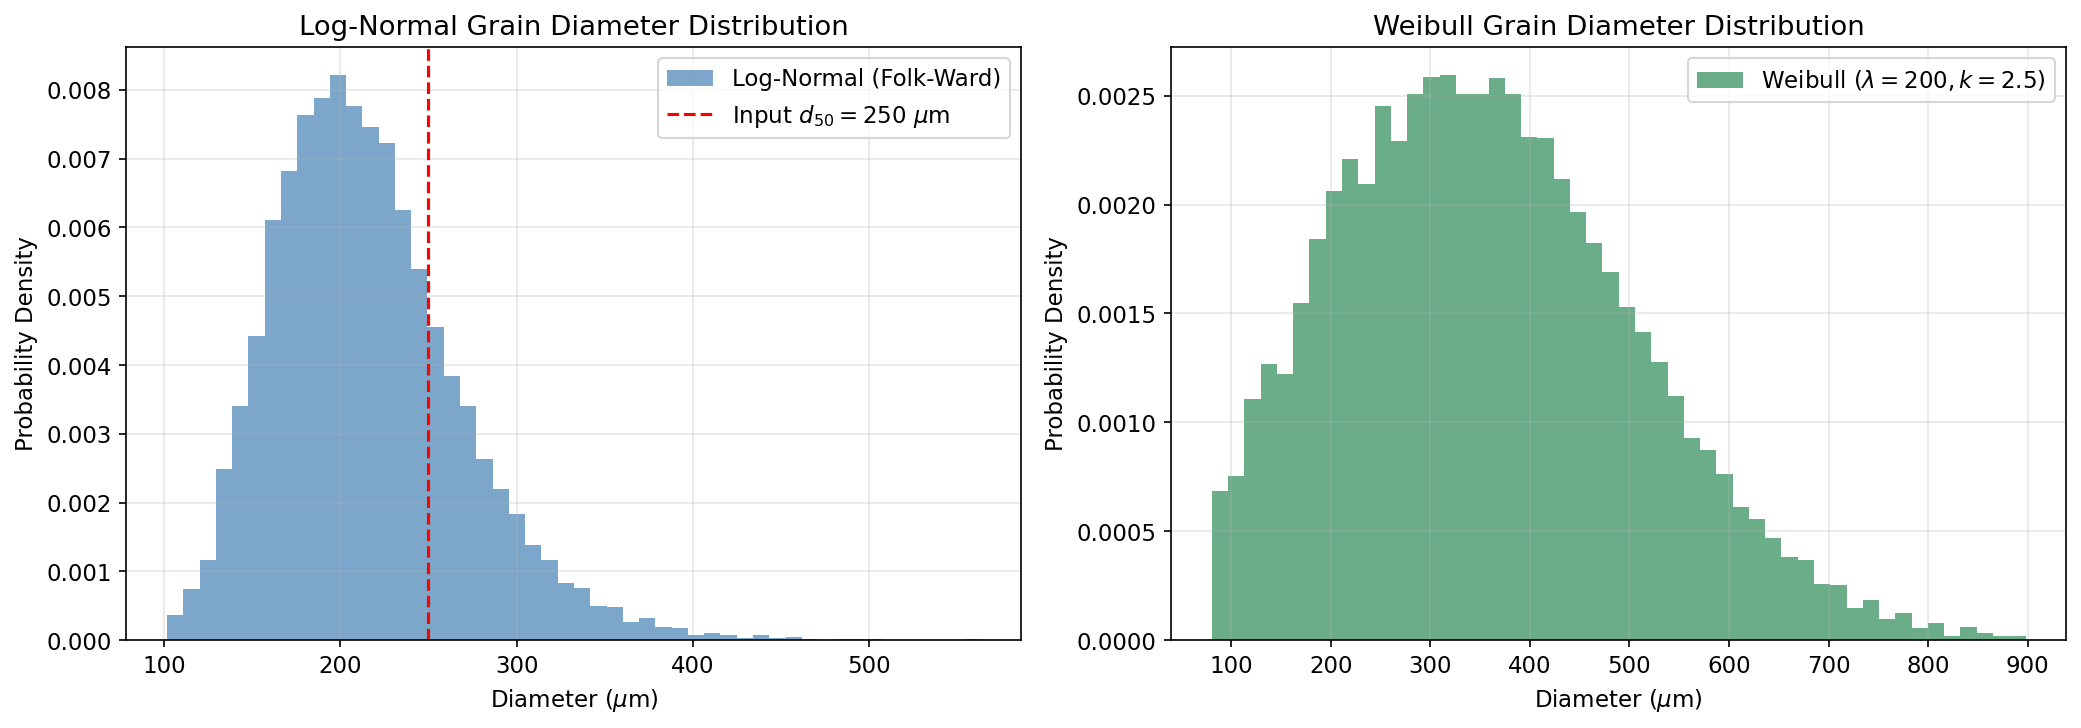

In [2]:
# 1. Geological Log-Normal PSD (Well-sorted medium sand: d50 = 250 um, sigma_phi = 0.35)
psd_lognormal = pp.LogNormalPSD(d50=250.0, sigma_phi=0.35, bounds=(50.0, 500.0))

# 2. Weibull PSD (Skewed grain distribution)
psd_weibull = pp.WeibullPSD(scale=200.0, shape=2.5, bounds=(40.0, 450.0))

# Sample 10,000 grain radii
radii_ln = psd_lognormal.sample(10000, rng=np.random.default_rng(42))
radii_wb = psd_weibull.sample(10000, rng=np.random.default_rng(42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(radii_ln * 2.0, bins=50, density=True, alpha=0.7, color='steelblue', label='Log-Normal (Folk-Ward)')
axes[0].axvline(250.0, color='red', linestyle='--', label=r'Input $d_{50} = 250\ \mu\mathrm{m}$')
axes[0].set_title('Log-Normal Grain Diameter Distribution')
axes[0].set_xlabel(r'Diameter ($\mu\mathrm{m}$)')
axes[0].set_ylabel('Probability Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(radii_wb * 2.0, bins=50, density=True, alpha=0.7, color='seagreen', label=r'Weibull ($\lambda=200, k=2.5$)')
axes[1].set_title('Weibull Grain Diameter Distribution')
axes[1].set_xlabel(r'Diameter ($\mu\mathrm{m}$)')
axes[1].set_ylabel('Probability Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 2. Accelerated Random Sequential Adsorption (RSA)

Standard RSA algorithms suffer from $O(N^2)$ pairwise checking, taking minutes to hours for large systems.
`poropack.RSAGenerator` uses an $O(1)$ spatial hash grid (`PeriodicSpatialGrid`) with toroidal periodic boundary conditions, placing thousands of non-overlapping spheres in milliseconds.


RSA Pack Generated:
  Spheres placed:      148
  Analytical Porosity: 0.6489
  Solid Volume:        3.51e+08 um^3
  Voxel Grid Dimensions: (100, 100, 100)
  Voxel Porosity:        0.6491


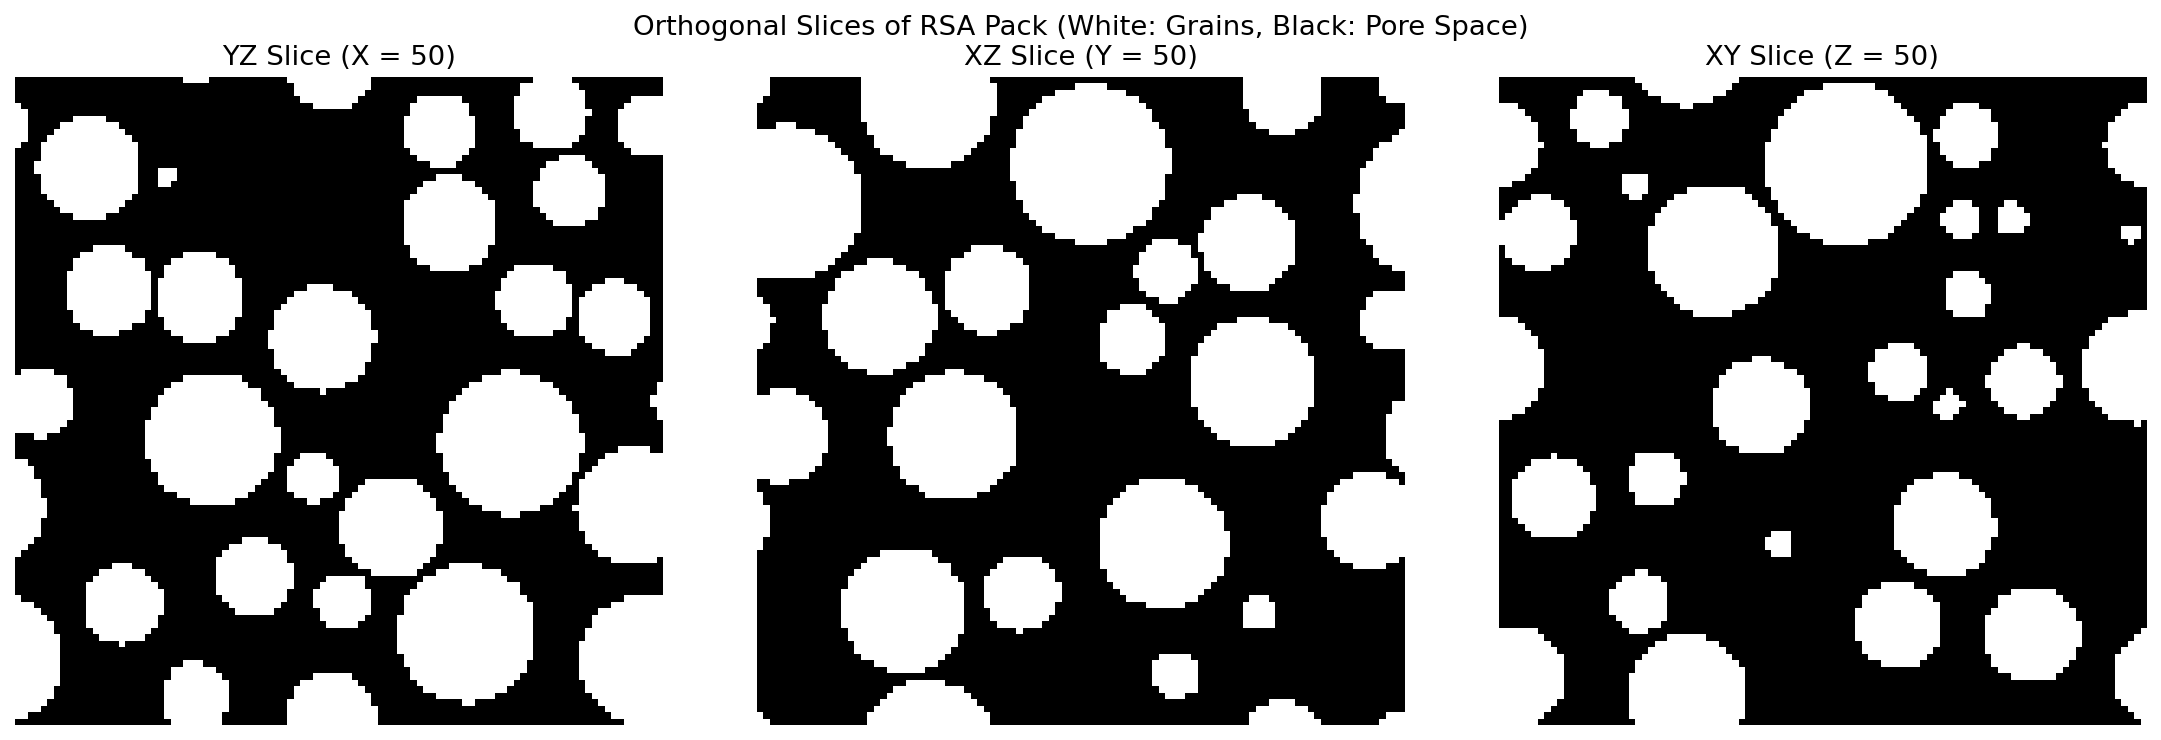

In [3]:
# Generate a 3D grain pack of size 1000 x 1000 x 1000 um
rsa_gen = pp.RSAGenerator(
    box_size=(1000.0, 1000.0, 1000.0),
    psd=psd_lognormal,
    min_throat=2.0,       # Minimum throat clearance between grains (um)
    periodic=(True, True, True),
    random_state=42,
)

# Target porosity of 0.65 (loose random assembly)
pack_rsa = rsa_gen.generate(target_porosity=0.65)
print('RSA Pack Generated:')
print(f'  Spheres placed:      {len(pack_rsa)}')
print(f'  Analytical Porosity: {pack_rsa.analytical_porosity():.4f}')
print(f'  Solid Volume:        {pack_rsa.solid_volume:.2e} um^3')

# Rasterize Lagrangian spheres into Eulerian VoxelGrid at 10 um resolution
voxel_rsa = pack_rsa.rasterize(voxel_size=10.0)
print(f'  Voxel Grid Dimensions: {voxel_rsa.shape}')
print(f'  Voxel Porosity:        {voxel_rsa.porosity():.4f}')

# Visualize orthogonal slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(voxel_rsa.matrix[50, :, :], cmap='bone')
axes[0].set_title('YZ Slice (X = 50)')
axes[1].imshow(voxel_rsa.matrix[:, 50, :], cmap='bone')
axes[1].set_title('XZ Slice (Y = 50)')
axes[2].imshow(voxel_rsa.matrix[:, :, 50], cmap='bone')
axes[2].set_title('XY Slice (Z = 50)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Orthogonal Slices of RSA Pack (White: Grains, Black: Pore Space)')
plt.tight_layout()
plt.show()


---
## 3. Ballistic Sedimentation ("Drop-and-Roll") under Gravity

Gravitational sedimentation models natural sedimentary rock deposition:
1. Grains drop vertically from the top of the domain.
2. Upon striking a resting grain or the substrate, the grain rolls along the steepest gradient on the spherical surface.
3. Upon striking a second grain, it rolls along the contact valley until reaching a stable 3-point mechanical equilibrium.
4. Boundaries wrap periodically in $(x,y)$ with a rigid floor at $z=0$.


Sedimentation Pack Generated:
  Grains deposited: 400
  Contact data available: True


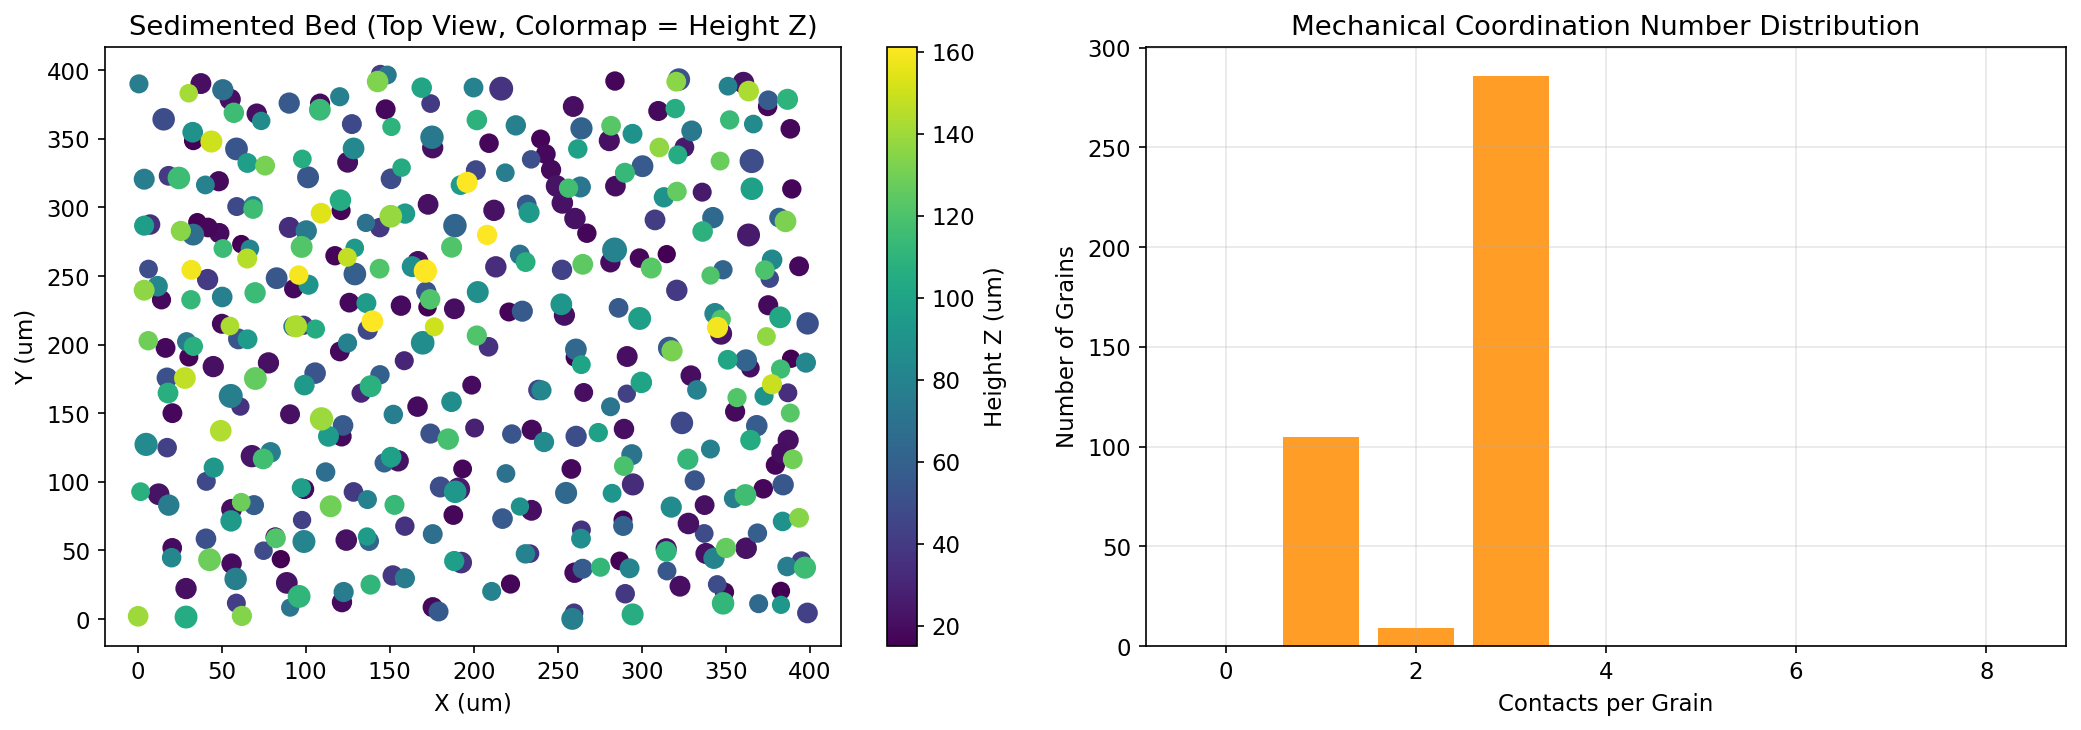

In [4]:
sed_gen = pp.SedimentationGenerator(
    box_size=(400.0, 400.0, 600.0),
    psd=pp.LogNormalPSD(d50=40.0, sigma_phi=0.25, bounds=(15.0, 60.0)),
    random_state=42,
)

pack_sed = sed_gen.generate(n_spheres=400)
print('Sedimentation Pack Generated:')
print(f'  Grains deposited: {len(pack_sed)}')
print(f'  Contact data available: {"contacts" in pack_sed.attributes}')

# X-ray projection and coordination histogram
contacts = pack_sed.attributes.get('contacts', [])
coord_nums = [len(c) for c in contacts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(pack_sed.coords[:, 0], pack_sed.coords[:, 1], c=pack_sed.coords[:, 2], s=pack_sed.radii*4, cmap='viridis')
axes[0].set_title('Sedimented Bed (Top View, Colormap = Height Z)')
axes[0].set_xlabel('X (um)')
axes[0].set_ylabel('Y (um)')
plt.colorbar(sc, ax=axes[0], label='Height Z (um)')

axes[1].hist(coord_nums, bins=range(0, 10), align='left', rwidth=0.8, color='darkorange', alpha=0.85)
axes[1].set_title('Mechanical Coordination Number Distribution')
axes[1].set_xlabel('Contacts per Grain')
axes[1].set_ylabel('Number of Grains')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4. Dense Random Packing via Force-Biased Algorithm (FBA + FIRE)

Random Sequential Adsorption (RSA) jams at low densities ($\phi pprox 0.35$).
`poropack.DensePackingGenerator` uses the Force-Biased Algorithm with Hookean repulsive contact forces and the Fast Inertial Relaxation Engine (FIRE) to collectively rearrange grains, breaking the RSA jamming limit and achieving dense random close packings with zero particle overlap.


In [5]:
dense_gen = pp.DensePackingGenerator(
    box_size=(150.0, 150.0, 150.0),
    psd=pp.LogNormalPSD(d50=25.0, sigma_phi=0.2, bounds=(10.0, 35.0)),
    random_state=42,
)

# Staged inflation to dense random close packing
pack_dense = dense_gen.generate(n_spheres=250, target_solid_fraction=0.60)
phi_solid = 1.0 - pack_dense.analytical_porosity()

print('Dense Random Packing Result:')
print(f'  Solid volume fraction (phi): {phi_solid:.4f}')
print(f'  Porosity:                    {pack_dense.analytical_porosity():.4f}')
print('  RSA Jamming Limit:           ~0.35 (Successfully Broken!)')


Dense Random Packing Result:
  Solid volume fraction (phi): 0.5999
  Porosity:                    0.4001
  RSA Jamming Limit:           ~0.35 (Successfully Broken!)


---
## 5. Continuum Bicontinuous Media via Spectral GRF & QSGS

For carbonates, vuggy rocks, and micro-porous media where grain boundaries are not spherical, `poropack` provides:
1. **Spectral Gaussian Random Fields (GRF)**: 3D spatial filtering in Fourier space with Gaussian, Exponential, or Von Kármán covariance kernels, thresholded via exact inverse-CDF for precision porosity matching.
2. **Quartet Structure Generation Set (QSGS)**: Stochastic seed growth imitating nucleation and cluster aggregation.


GRF Target Porosity: 0.30, Actual Porosity:  0.3004
QSGS Target Porosity: 0.30, Actual Porosity: 0.2677


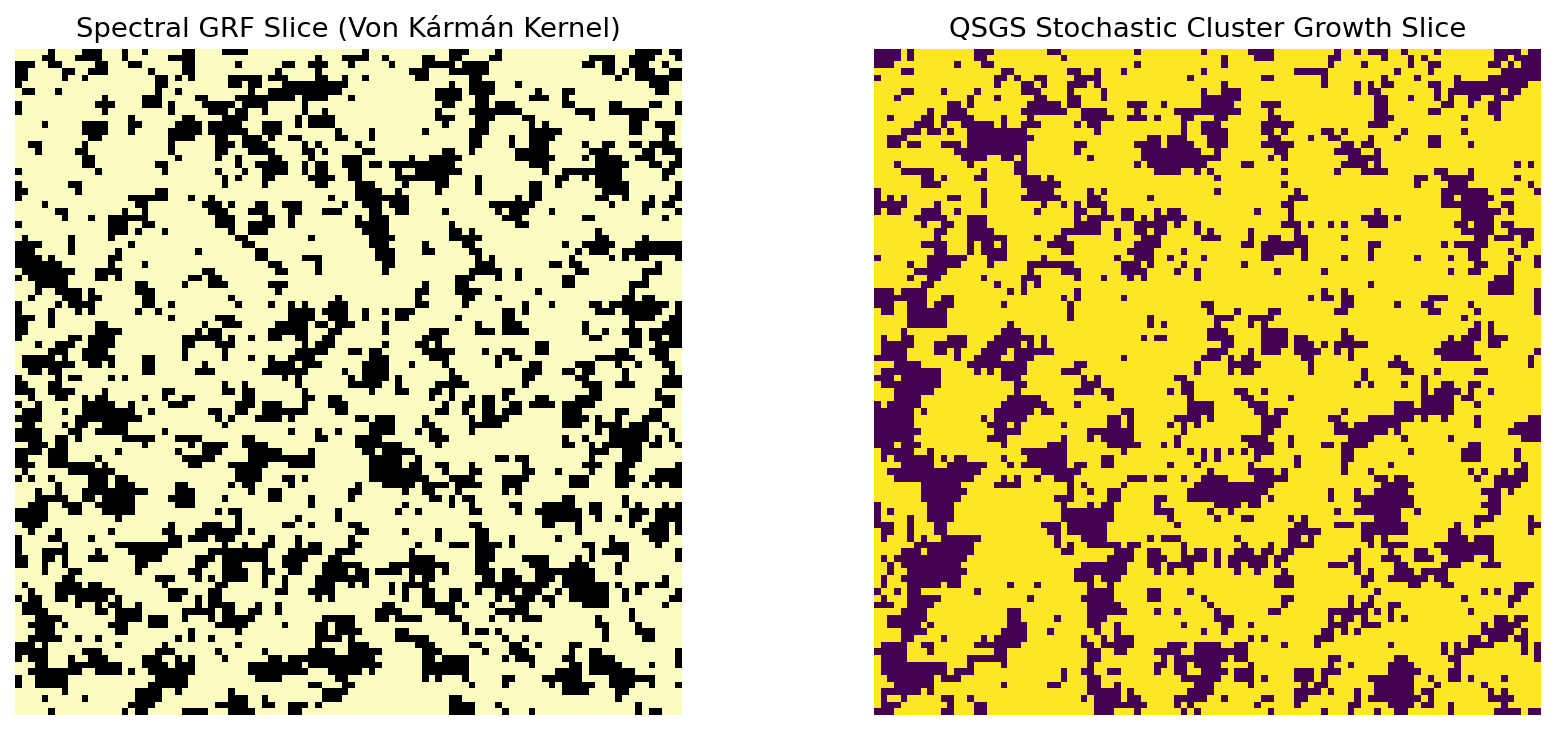

In [6]:
# 1. Spectral Gaussian Random Field (Von Karman kernel for self-affine roughness)
grf = pp.GaussianRandomField(
    shape=(100, 100, 100),
    voxel_size=2.0,
    correlation_length=16.0,
    kernel='von_karman',
    random_state=42,
)
voxel_grf = grf.generate(target_porosity=0.30)

# 2. QSGS Stochastic Matrix
qsgs = pp.QSGSGenerator(
    shape=(100, 100, 100),
    voxel_size=2.0,
    core_probability=0.01,
    random_state=42,
)
voxel_qsgs = qsgs.generate(target_porosity=0.30)

print(f'GRF Target Porosity: 0.30, Actual Porosity:  {voxel_grf.porosity():.4f}')
print(f'QSGS Target Porosity: 0.30, Actual Porosity: {voxel_qsgs.porosity():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(voxel_grf.matrix[50, :, :], cmap='magma')
axes[0].set_title('Spectral GRF Slice (Von Kármán Kernel)')
axes[0].axis('off')

axes[1].imshow(voxel_qsgs.matrix[50, :, :], cmap='viridis')
axes[1].set_title('QSGS Stochastic Cluster Growth Slice')
axes[1].axis('off')
plt.tight_layout()
plt.show()


---
## 6. Post-Depositional Diagenetic Transformations

Reservoir sandstones undergo burial and diagenesis:
1. **Mechanical Compaction**: Uniaxial vertical strain squashes the matrix, inducing grain interpenetration and reducing bulk porosity.
2. **Syntaxial Cementation**: Mineral precipitation (quartz overgrowths, pore-filling calcite) modeled via Euclidean Distance Transform (EDT) dilation, constricting pore throats.
3. **Dissolution**: Leaching of unstable minerals creating secondary microporosity or vugs.


Diagenetic Porosity Evolution:
  1. Depositional Porosity: 0.6341
  2. Compacted Porosity:    0.6336
  3. Cemented Porosity:     0.4216
  4. Dissolved Porosity:    0.6141


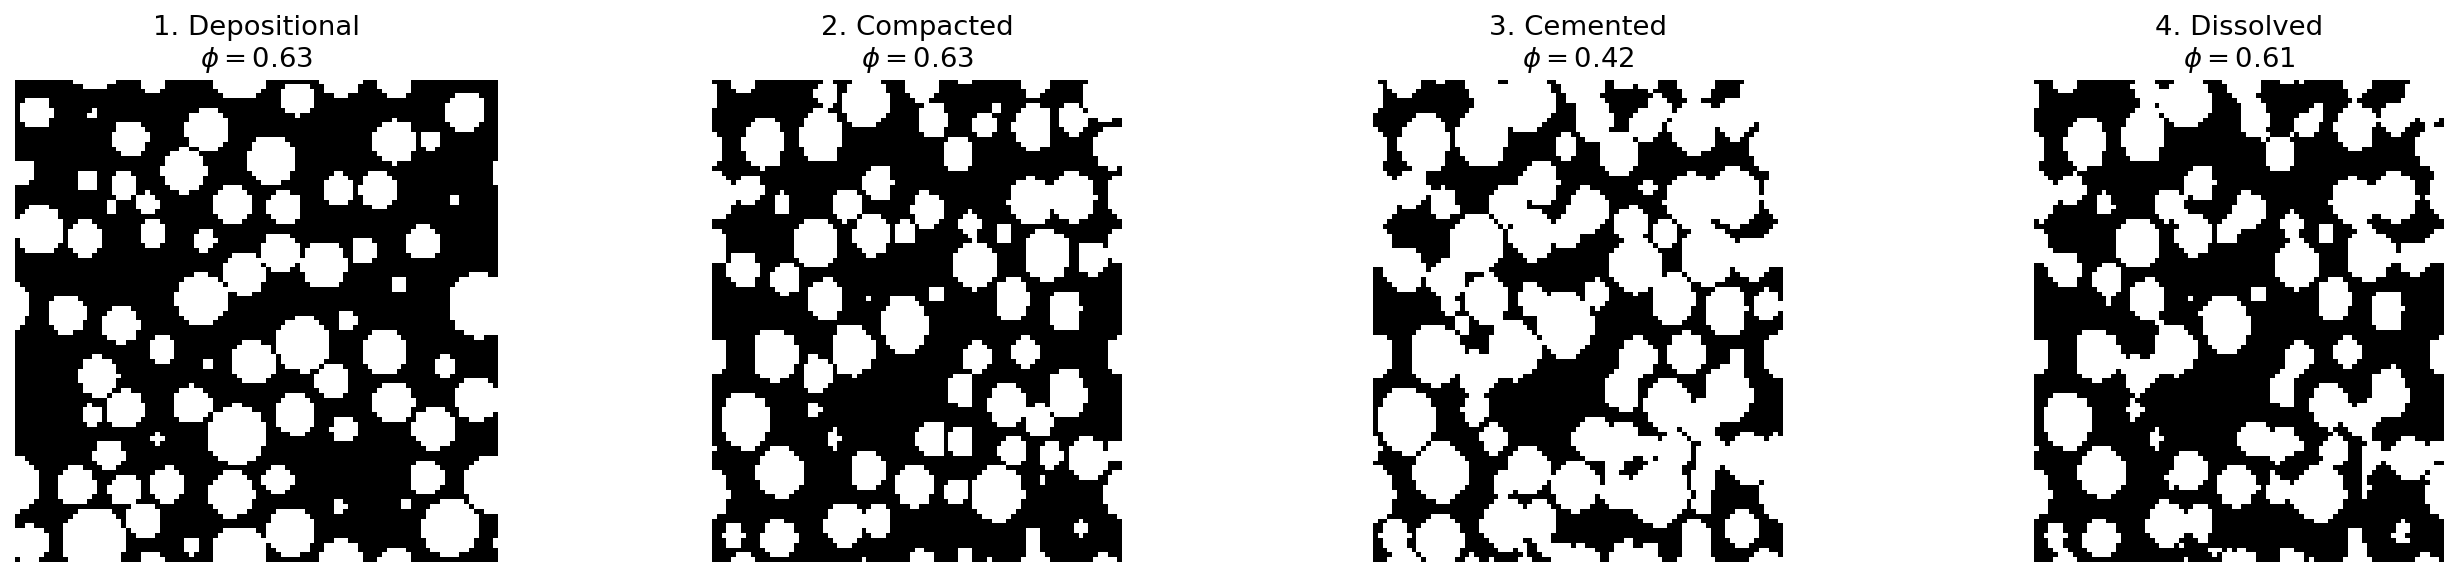

In [7]:
# Begin with a base RSA pack
base_pack = pp.RSAGenerator(
    box_size=(300.0, 300.0, 300.0),
    psd=pp.LogNormalPSD(d50=35.0, sigma_phi=0.25),
    random_state=42,
).generate(target_porosity=0.55)

grid_depositional = base_pack.rasterize(voxel_size=3.0)

# Stage 1: 15% Uniaxial Vertical Compaction
grid_compacted = pp.apply_compaction(grid_depositional, vertical_strain=0.15)

# Stage 2: 10% Quartz Overgrowth Cementation
grid_cemented = pp.apply_cementation(grid_compacted, cement_fraction=0.10)

# Stage 3: 5% Secondary Leaching / Dissolution
grid_dissolved = pp.apply_dissolution(grid_cemented, dissolution_fraction=0.05, mode='grain_boundary')

print('Diagenetic Porosity Evolution:')
print(f'  1. Depositional Porosity: {grid_depositional.porosity():.4f}')
print(f'  2. Compacted Porosity:    {grid_compacted.porosity():.4f}')
print(f'  3. Cemented Porosity:     {grid_cemented.porosity():.4f}')
print(f'  4. Dissolved Porosity:    {grid_dissolved.porosity():.4f}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(grid_depositional.matrix[50, :, :], cmap='bone')
axes[0].set_title(f'1. Depositional\n$\\phi = {grid_depositional.porosity():.2f}$')
axes[1].imshow(grid_compacted.matrix[int(50*0.85), :, :], cmap='bone')
axes[1].set_title(f'2. Compacted\n$\\phi = {grid_compacted.porosity():.2f}$')
axes[2].imshow(grid_cemented.matrix[int(50*0.85), :, :], cmap='bone')
axes[2].set_title(f'3. Cemented\n$\\phi = {grid_cemented.porosity():.2f}$')
axes[3].imshow(grid_dissolved.matrix[int(50*0.85), :, :], cmap='bone')
axes[3].set_title(f'4. Dissolved\n$\\phi = {grid_dissolved.porosity():.2f}$')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


---
## 7. Digital Rock Petrophysics Characterization

`poropack.petrophysics` provides a suite of characterization tools:
- **Porosity Partitioning**: Distinguishing percolating (effective) porosity from isolated dead-end voids via 3D flood-fill clustering.
- **Specific Surface Area ($S_v$)**: Matrix surface area per unit bulk volume.
- **Two-Point Autocorrelation ($S_2(r)$)**: Measures spatial correlation length and characteristic pore scales.
- **Chord Length Distribution**: Chord length probability density in the pore phase.
- **Kozeny-Carman Permeability**: Analytical permeability estimation.


Total Porosity:     0.4216 (42.16%)
Effective Porosity: 0.4211 (42.11%)
Isolated Porosity:  0.0005 (0.05%)
Percolating Axes:   X=True, Y=True, Z=True
Specific Surface Area (Sv): 0.0910 um^-1
Kozeny-Carman Permeability: 1827045356884199.25 mD


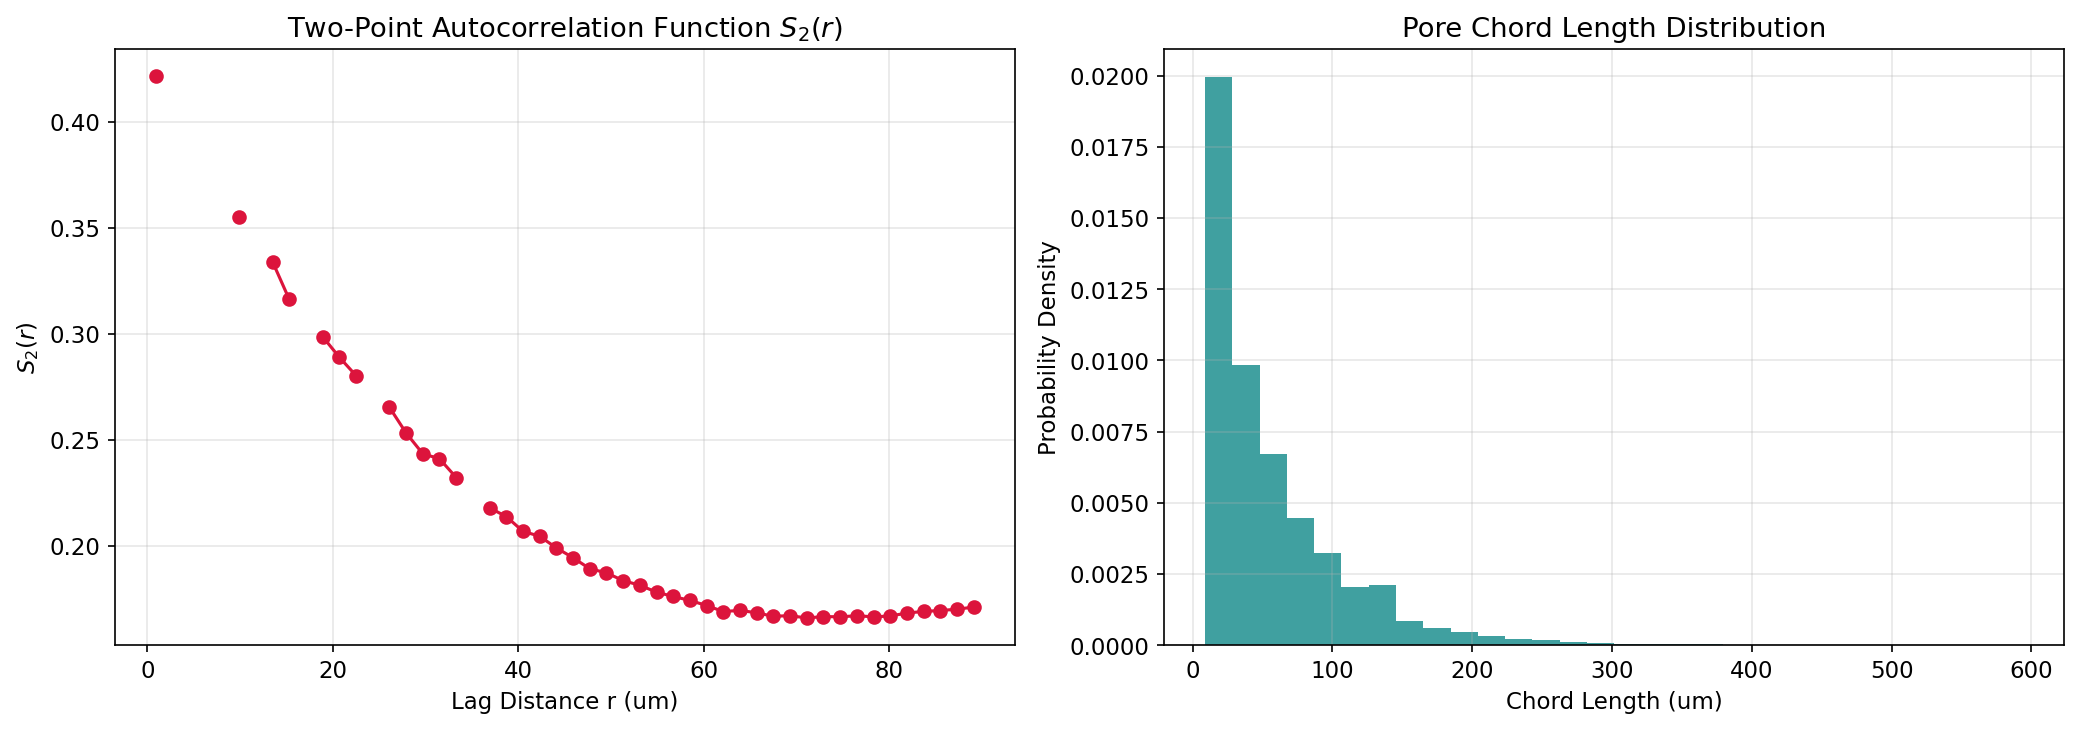

In [8]:
# Detailed porosity analysis
poro_res = pp.analyze_porosity(grid_cemented)
print(poro_res.summary())

# Specific surface area
sv = pp.specific_surface_area(grid_cemented)
print(f'Specific Surface Area (Sv): {sv:.4f} um^-1')

# Two-point correlation function S2(r)
radii_s2, s2_vals = pp.two_point_correlation(grid_cemented, max_radius=30)

# Chord length distribution
chords_pore = pp.chord_length_distribution(grid_cemented, phase='pore', axis=0)

# Kozeny-Carman Permeability
k_m2 = pp.kozeny_carman(grid_cemented)
k_mD = k_m2 / 9.869233e-16
print(f'Kozeny-Carman Permeability: {k_mD:.2f} mD')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(radii_s2 * grid_cemented.voxel_size, s2_vals, marker='o', color='crimson')
axes[0].set_title(r'Two-Point Autocorrelation Function $S_2(r)$')
axes[0].set_xlabel('Lag Distance r (um)')
axes[0].set_ylabel(r'$S_2(r)$')
axes[0].grid(True, alpha=0.3)

axes[1].hist(chords_pore * grid_cemented.voxel_size, bins=30, density=True, color='teal', alpha=0.75)
axes[1].set_title('Pore Chord Length Distribution')
axes[1].set_xlabel('Chord Length (um)')
axes[1].set_ylabel('Probability Density')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8. Pore Network Modeling (PNM) Bridge

Extract topological pore networks (pore bodies and throats) using the PoreSpy SNOW2 algorithm for downstream network flow simulations (e.g. OpenPNM).


In [9]:
# Extract pore network from sample voxel grid
try:
    net = pp.extract_pore_network(grid_cemented)
    print('SNOW2 Pore Network Extraction Successful:')
    print(f'  Number of pore bodies:  {len(net["pore.coords"])}')
    print(f'  Number of pore throats: {len(net["throat.conns"])}')
    print(f'  Mean pore diameter:     {2.0 * np.mean(net["pore.equivalent_diameter"]):.2f} um')
    print(f'  Mean throat diameter:   {2.0 * np.mean(net["throat.equivalent_diameter"]):.2f} um')
except Exception as e:
    print(f'PoreSpy SNOW2 execution note: {e}')


[00:18:54] WARNING  Image was cropped to (100, 100, 84) during    _snow2.py:288
                    watershed                                                  
PoreSpy SNOW2 execution note: The trimesh package can be installed with pip install trimesh


---
## 9. Simulation & Visualization Exporters

Export porous media representations to industry-standard simulation and visualization formats:
- **3D TIFF Stacks**: Compatible with ImageJ, Fiji, Avizo, and Dragonfly.
- **VTK (`.vti` & `.vtp`)**: For 3D volumetric rendering in ParaView.
- **MRST `.mat`**: Formatted for direct loading into MATLAB Reservoir Simulation Toolbox (MRST).
- **CSV & Raw Binary**: High-throughput coordinates and raw voxel arrays.


In [10]:
import os

# 1. Export 3D TIFF stack
pp.export_tiff(grid_cemented, 'sample_porous_media.tif')

# 2. Export MRST-compatible .mat struct
pp.export_mrst_mat(grid_cemented, 'sample_mrst_grid.mat', permeability_mD=k_mD)

# 3. Export VTK ImageData (.vti)
pp.export_vtk_vti(grid_cemented, 'sample_volume.vti')

# 4. Export Lagrangian sphere pack to CSV
base_pack.to_csv('sample_grains.csv')

print('Export verification:')
for f in ['sample_porous_media.tif', 'sample_mrst_grid.mat', 'sample_volume.vti', 'sample_grains.csv']:
    if os.path.exists(f):
        print(f'  File: {f:25s} Size: {os.path.getsize(f)/1024:.1f} KB')
        os.remove(f)  # Clean up temporary demonstration files


Export verification:
  File: sample_porous_media.tif   Size: 843.9 KB
  File: sample_mrst_grid.mat      Size: 140.1 KB
  File: sample_volume.vti         Size: 113.5 KB
  File: sample_grains.csv         Size: 59.7 KB


---
## 10. Backward Compatibility with Legacy API

To ensure zero disruption to existing scripts, the legacy `generate_spherepack` class in `genrandsp.py` is fully preserved as a backward-compatible wrapper delegating to modern `poropack` routines.


In [11]:
from genrandsp import generate_spherepack

# Initialize using the legacy API syntax
gsp = generate_spherepack(box_dim=[100, 100, 100], radii=[12, 8, 4], throat_limit=1.0)

# Generate spheres targeting porosity
spheres_legacy = gsp.method_I(target_porosity=0.60)
print(f'Legacy method_I successfully generated {len(spheres_legacy)} spheres!')



Final state: n_spheres=445, porosity=0.7496
Number of spheres of each size : {12: 11, 8: 29, 4: 405}
Legacy method_I successfully generated 445 spheres!
